In [1]:

%pip -q install gymnasium


Note: you may need to restart the kernel to use updated packages.


## Imports + env factory + helpers

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, deque

try:
    import gymnasium as gym
    _USE_GYMNASIUM = True
except ImportError:
    import gym  # fallback
    _USE_GYMNASIUM = False


def make_env(seed: int = 0):
    env = gym.make("Taxi-v3")
    # Gymnasium reset returns (obs, info); old gym returns obs
    if _USE_GYMNASIUM:
        env.reset(seed=seed)
    else:
        try:
            env.seed(seed)
        except Exception:
            pass
        env.reset()
    return env


def epsilon_greedy_action(Q, s, n_actions: int, eps: float, rng: np.random.Generator):
    if rng.random() < eps:
        return int(rng.integers(0, n_actions))
    return int(np.argmax(Q[s]))


def moving_average(x, window=100):
    if len(x) == 0:
        return np.array([])
    w = min(window, len(x))
    out = np.empty(len(x))
    dq = deque()
    s = 0.0
    for i, v in enumerate(x):
        dq.append(v); s += v
        if len(dq) > w:
            s -= dq.popleft()
        out[i] = s / len(dq)
    return out


## Monte Carlo Control (every-visit, epsilon-greedy)

In [3]:
def train_mc_control_taxi(
    num_episodes=20_000,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_episodes=15_000,
    seed=0
):
    env = make_env(seed)
    n_actions = env.action_space.n

    Q = defaultdict(lambda: np.zeros(n_actions, dtype=np.float32))
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)

    rng = np.random.default_rng(seed)

    ep_returns = []
    ep_lengths = []
    eps_values = []

    for ep in range(num_episodes):
        # Linear epsilon decay
        frac = min(1.0, ep / max(1, eps_decay_episodes))
        eps = eps_start + frac * (eps_end - eps_start)
        eps_values.append(eps)

        reset_out = env.reset()
        s = reset_out[0] if _USE_GYMNASIUM else reset_out

        trajectory = []  # (s, a, r)

        done = False
        total_r = 0.0
        steps = 0

        while not done:
            a = epsilon_greedy_action(Q, s, n_actions, eps, rng)

            step_out = env.step(a)
            if _USE_GYMNASIUM:
                s2, r, terminated, truncated, _info = step_out
                done = terminated or truncated
            else:
                s2, r, done, _info = step_out

            trajectory.append((s, a, r))
            total_r += r
            steps += 1
            s = s2

        # Every-visit MC updates
        G = 0.0
        for (s_t, a_t, r_t) in reversed(trajectory):
            G = r_t + gamma * G
            key = (s_t, a_t)
            returns_sum[key] += G
            returns_count[key] += 1
            Q[s_t][a_t] = returns_sum[key] / returns_count[key]

        ep_returns.append(total_r)
        ep_lengths.append(steps)

    env.close()
    return {
        "name": "MC",
        "Q": Q,
        "ep_returns": np.array(ep_returns, dtype=np.float32),
        "ep_lengths": np.array(ep_lengths, dtype=np.int32),
        "eps": np.array(eps_values, dtype=np.float32),
    }


## SARSA (TD control, on-policy)

In [4]:
def train_sarsa_taxi(
    num_episodes=20_000,
    alpha=0.1,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_episodes=15_000,
    seed=0
):
    env = make_env(seed)
    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions, dtype=np.float32))

    rng = np.random.default_rng(seed)

    ep_returns = []
    ep_lengths = []
    eps_values = []

    for ep in range(num_episodes):
        frac = min(1.0, ep / max(1, eps_decay_episodes))
        eps = eps_start + frac * (eps_end - eps_start)
        eps_values.append(eps)

        reset_out = env.reset()
        s = reset_out[0] if _USE_GYMNASIUM else reset_out

        a = epsilon_greedy_action(Q, s, n_actions, eps, rng)

        done = False
        total_r = 0.0
        steps = 0

        while not done:
            step_out = env.step(a)
            if _USE_GYMNASIUM:
                s2, r, terminated, truncated, _info = step_out
                done = terminated or truncated
            else:
                s2, r, done, _info = step_out

            a2 = epsilon_greedy_action(Q, s2, n_actions, eps, rng) if not done else 0

            td_target = r + (0.0 if done else gamma * Q[s2][a2])
            td_error = td_target - Q[s][a]
            Q[s][a] += alpha * td_error

            total_r += r
            steps += 1
            s, a = s2, a2

        ep_returns.append(total_r)
        ep_lengths.append(steps)

    env.close()
    return {
        "name": "SARSA",
        "Q": Q,
        "ep_returns": np.array(ep_returns, dtype=np.float32),
        "ep_lengths": np.array(ep_lengths, dtype=np.int32),
        "eps": np.array(eps_values, dtype=np.float32),
    }


## Q-learning (TD control, off-policy)

In [5]:
def train_q_learning_taxi(
    num_episodes=20_000,
    alpha=0.1,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_episodes=15_000,
    seed=0
):
    env = make_env(seed)
    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions, dtype=np.float32))

    rng = np.random.default_rng(seed)

    ep_returns = []
    ep_lengths = []
    eps_values = []

    for ep in range(num_episodes):
        frac = min(1.0, ep / max(1, eps_decay_episodes))
        eps = eps_start + frac * (eps_end - eps_start)
        eps_values.append(eps)

        reset_out = env.reset()
        s = reset_out[0] if _USE_GYMNASIUM else reset_out

        done = False
        total_r = 0.0
        steps = 0

        while not done:
            a = epsilon_greedy_action(Q, s, n_actions, eps, rng)

            step_out = env.step(a)
            if _USE_GYMNASIUM:
                s2, r, terminated, truncated, _info = step_out
                done = terminated or truncated
            else:
                s2, r, done, _info = step_out

            best_next = 0.0 if done else np.max(Q[s2])
            td_target = r + gamma * best_next
            td_error = td_target - Q[s][a]
            Q[s][a] += alpha * td_error

            total_r += r
            steps += 1
            s = s2

        ep_returns.append(total_r)
        ep_lengths.append(steps)

    env.close()
    return {
        "name": "Q-learning",
        "Q": Q,
        "ep_returns": np.array(ep_returns, dtype=np.float32),
        "ep_lengths": np.array(ep_lengths, dtype=np.int32),
        "eps": np.array(eps_values, dtype=np.float32),
    }


# RUN

In [6]:
NUM_EPISODES = 20_000
SEED = 42

mc = train_mc_control_taxi(num_episodes=NUM_EPISODES, seed=SEED)
sarsa = train_sarsa_taxi(num_episodes=NUM_EPISODES, alpha=0.1, seed=SEED)
qlearn = train_q_learning_taxi(num_episodes=NUM_EPISODES, alpha=0.1, seed=SEED)

runs = [mc, sarsa, qlearn]
[(r["name"], float(r["ep_returns"][-1]), int(r["ep_lengths"][-1])) for r in runs][:3]


[('MC', 9.0, 12), ('SARSA', 9.0, 12), ('Q-learning', 15.0, 6)]

## Plots (returns + episode length)

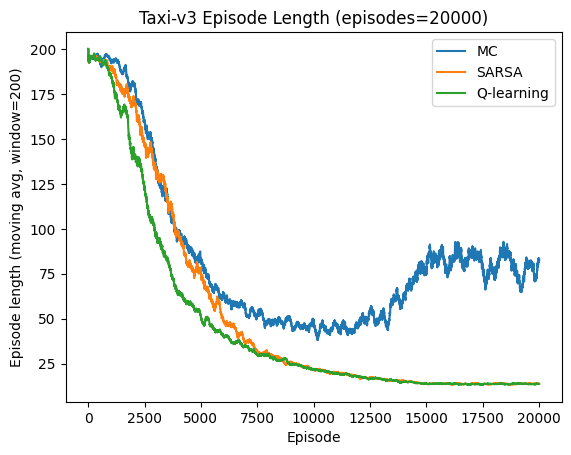

In [7]:
def plot_learning_curves(runs, window=200, title_suffix=""):
    plt.figure()
    for r in runs:
        y = moving_average(r["ep_returns"], window=window)
        plt.plot(y, label=r["name"])
    plt.xlabel("Episode")
    plt.ylabel(f"Return (moving avg, window={window})")
    plt.title(f"Taxi-v3 Learning Curves {title_suffix}".strip())
    plt.legend()
    plt.show()

    plt.figure()
    for r in runs:
        y = moving_average(r["ep_lengths"], window=window)
        plt.plot(y, label=r["name"])
    plt.xlabel("Episode")
    plt.ylabel(f"Episode length (moving avg, window={window})")
    plt.title(f"Taxi-v3 Episode Length {title_suffix}".strip())
    plt.legend()
    plt.show()


plot_learning_curves(runs, window=200, title_suffix=f"(episodes={NUM_EPISODES})")


## Greedy evaluation (no exploration)

In [8]:
def evaluate_greedy(Q, num_episodes=200, seed=123):
    env = make_env(seed)
    n_actions = env.action_space.n
    rng = np.random.default_rng(seed)

    returns = []
    lengths = []

    for ep in range(num_episodes):
        reset_out = env.reset()
        s = reset_out[0] if _USE_GYMNASIUM else reset_out

        done = False
        total_r = 0.0
        steps = 0

        while not done:
            # Greedy action; if unseen state, default zeros -> argmax=0
            a = int(np.argmax(Q[s])) if s in Q else 0

            step_out = env.step(a)
            if _USE_GYMNASIUM:
                s2, r, terminated, truncated, _info = step_out
                done = terminated or truncated
            else:
                s2, r, done, _info = step_out

            total_r += r
            steps += 1
            s = s2

        returns.append(total_r)
        lengths.append(steps)

    env.close()
    return float(np.mean(returns)), float(np.mean(lengths))


for r in runs:
    mean_ret, mean_len = evaluate_greedy(r["Q"], num_episodes=300, seed=999)
    print(f"{r['name']:>9} | greedy mean return: {mean_ret:7.2f} | greedy mean length: {mean_len:7.2f}")


       MC | greedy mean return: -116.12 | greedy mean length:  124.59
    SARSA | greedy mean return:    7.63 | greedy mean length:   13.37
Q-learning | greedy mean return:    7.64 | greedy mean length:   13.36


## TD Error Logging for SARSA and Q

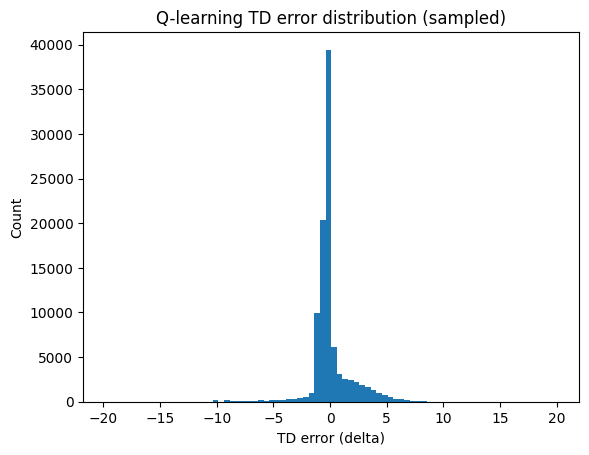

In [9]:
def train_q_learning_with_td_error_logging(
    num_episodes=10_000,
    alpha=0.1,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_episodes=8_000,
    seed=0,
    log_every_steps=1
):
    env = make_env(seed)
    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions, dtype=np.float32))
    rng = np.random.default_rng(seed)

    ep_returns = []
    ep_lengths = []
    eps_values = []
    td_errors = []

    step_counter = 0

    for ep in range(num_episodes):
        frac = min(1.0, ep / max(1, eps_decay_episodes))
        eps = eps_start + frac * (eps_end - eps_start)
        eps_values.append(eps)

        reset_out = env.reset()
        s = reset_out[0] if _USE_GYMNASIUM else reset_out

        done = False
        total_r = 0.0
        steps = 0

        while not done:
            a = epsilon_greedy_action(Q, s, n_actions, eps, rng)

            step_out = env.step(a)
            if _USE_GYMNASIUM:
                s2, r, terminated, truncated, _info = step_out
                done = terminated or truncated
            else:
                s2, r, done, _info = step_out

            best_next = 0.0 if done else np.max(Q[s2])
            td_target = r + gamma * best_next
            td_error = float(td_target - Q[s][a])
            Q[s][a] += alpha * td_error

            step_counter += 1
            if (step_counter % log_every_steps) == 0:
                td_errors.append(td_error)

            total_r += r
            steps += 1
            s = s2

        ep_returns.append(total_r)
        ep_lengths.append(steps)

    env.close()
    return {
        "name": "Q-learning (tdlog)",
        "Q": Q,
        "ep_returns": np.array(ep_returns, dtype=np.float32),
        "ep_lengths": np.array(ep_lengths, dtype=np.int32),
        "eps": np.array(eps_values, dtype=np.float32),
        "td_errors": np.array(td_errors, dtype=np.float32),
    }


qlog = train_q_learning_with_td_error_logging(num_episodes=10_000, seed=7, log_every_steps=5)

plt.figure()
plt.hist(qlog["td_errors"], bins=80)
plt.xlabel("TD error (delta)")
plt.ylabel("Count")
plt.title("Q-learning TD error distribution (sampled)")
plt.show()


## TEIL A: Reproduzierbare Evaluation mit 5 Seeds
## A1 — Alle Algorithmen mit 5 Seeds trainieren

In [ ]:
SEEDS = [0, 1, 2, 3, 4]
NUM_EPISODES = 20_000

results = {
    "MC": [],
    "SARSA": [],
    "Q-Learning": []
}

print("Training alle Algorithmen mit 5 Seeds...")
for seed in SEEDS:
    print(f"  Seed {seed}...", end=" ")

    mc = train_mc_control_taxi(num_episodes=NUM_EPISODES, seed=seed)
    results["MC"].append(mc)

    sarsa = train_sarsa_taxi(num_episodes=NUM_EPISODES, seed=seed)
    results["SARSA"].append(sarsa)

    qlearn = train_q_learning_taxi(num_episodes=NUM_EPISODES, seed=seed)
    results["Q-Learning"].append(qlearn)

    print("✓")

print(f"✓ Training abgeschlossen für 5 Seeds")


## A1 — Greedy Evaluation für alle Runs

In [ ]:
greedy_results = {
    "MC": {"returns": [], "lengths": []},
    "SARSA": {"returns": [], "lengths": []},
    "Q-Learning": {"returns": [], "lengths": []}
}

print("Greedy Evaluation (300 Episoden pro Run)...")
for alg_name in ["MC", "SARSA", "Q-Learning"]:
    for i, run in enumerate(results[alg_name]):
        mean_ret, mean_len = evaluate_greedy(run["Q"], num_episodes=300, seed=999+i)
        greedy_results[alg_name]["returns"].append(mean_ret)
        greedy_results[alg_name]["lengths"].append(mean_len)

# Zusammenfassung ausgeben
print("\n" + "="*80)
print("GREEDY EVALUATION RESULTS (Mean ± Std über 5 Seeds)")
print("="*80)
for alg_name in ["MC", "SARSA", "Q-Learning"]:
    returns = np.array(greedy_results[alg_name]["returns"])
    lengths = np.array(greedy_results[alg_name]["lengths"])
    print(f"\n{alg_name}:")
    print(f"  Mean Return:  {returns.mean():7.2f} ± {returns.std():6.2f}")
    print(f"  Mean Length:  {lengths.mean():7.2f} ± {lengths.std():6.2f}")
print("="*80)


## A2 — Visualisierung 1: Learning Curves mit Mittelwert + Streuung

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# === Returns Plot ===
ax = axes[0]
for alg_name, color in [("MC", "red"), ("SARSA", "blue"), ("Q-Learning", "green")]:
    runs = results[alg_name]

    # Individual runs als dünne Linien
    for run in runs:
        ma = moving_average(run["ep_returns"], window=200)
        ax.plot(ma, alpha=0.3, color=color, linewidth=0.8)

    # Mittelwert als dicke Linie
    all_ma = np.array([moving_average(run["ep_returns"], window=200) for run in runs])
    mean_ma = all_ma.mean(axis=0)
    std_ma = all_ma.std(axis=0)
    ax.plot(mean_ma, label=f"{alg_name} (Mean)", color=color, linewidth=2.5)
    ax.fill_between(np.arange(len(mean_ma)), mean_ma - std_ma, mean_ma + std_ma,
                     alpha=0.2, color=color)

ax.set_xlabel("Episode", fontsize=12)
ax.set_ylabel("Return (Moving Avg, window=200)", fontsize=12)
ax.set_title("Learning Curves: Return über Episoden", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# === Episode Length Plot ===
ax = axes[1]
for alg_name, color in [("MC", "red"), ("SARSA", "blue"), ("Q-Learning", "green")]:
    runs = results[alg_name]

    # Individual runs
    for run in runs:
        ma = moving_average(run["ep_lengths"], window=200)
        ax.plot(ma, alpha=0.3, color=color, linewidth=0.8)

    # Mittelwert
    all_ma = np.array([moving_average(run["ep_lengths"], window=200) for run in runs])
    mean_ma = all_ma.mean(axis=0)
    std_ma = all_ma.std(axis=0)
    ax.plot(mean_ma, label=f"{alg_name} (Mean)", color=color, linewidth=2.5)
    ax.fill_between(np.arange(len(mean_ma)), mean_ma - std_ma, mean_ma + std_ma,
                     alpha=0.2, color=color)

ax.set_xlabel("Episode", fontsize=12)
ax.set_ylabel("Episode Length (Moving Avg, window=200)", fontsize=12)
ax.set_title("Learning Curves: Episode Länge über Episoden", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("01_learning_curves_with_seeds.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Saved: 01_learning_curves_with_seeds.png")


## A2 — Visualisierung 2: Greedy Evaluation Bar Chart

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

algorithms = ["MC", "SARSA", "Q-Learning"]
colors = ["red", "blue", "green"]

# === Returns Bar Chart ===
ax = axes[0]
x_pos = np.arange(len(algorithms))
returns_means = [np.mean(greedy_results[alg]["returns"]) for alg in algorithms]
returns_stds = [np.std(greedy_results[alg]["returns"]) for alg in algorithms]

bars = ax.bar(x_pos, returns_means, yerr=returns_stds, capsize=10,
              color=colors, alpha=0.7, edgecolor="black", linewidth=1.5)
ax.set_ylabel("Mean Return", fontsize=12, fontweight="bold")
ax.set_title("Greedy Evaluation: Mean Return (±Std) über 5 Seeds", fontsize=13, fontweight="bold")
ax.set_xticks(x_pos)
ax.set_xticklabels(algorithms, fontsize=11)
ax.grid(axis="y", alpha=0.3)

# Werte auf Balken drucken
for i, (mean, std) in enumerate(zip(returns_means, returns_stds)):
    ax.text(i, mean + std + 0.5, f"{mean:.1f}±{std:.1f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

# === Episode Length Bar Chart ===
ax = axes[1]
lengths_means = [np.mean(greedy_results[alg]["lengths"]) for alg in algorithms]
lengths_stds = [np.std(greedy_results[alg]["lengths"]) for alg in algorithms]

bars = ax.bar(x_pos, lengths_means, yerr=lengths_stds, capsize=10,
              color=colors, alpha=0.7, edgecolor="black", linewidth=1.5)
ax.set_ylabel("Mean Episode Length", fontsize=12, fontweight="bold")
ax.set_title("Greedy Evaluation: Mean Episode Length (±Std) über 5 Seeds", fontsize=13, fontweight="bold")
ax.set_xticks(x_pos)
ax.set_xticklabels(algorithms, fontsize=11)
ax.grid(axis="y", alpha=0.3)

# Werte auf Balken
for i, (mean, std) in enumerate(zip(lengths_means, lengths_stds)):
    ax.text(i, mean + std + 0.1, f"{mean:.1f}±{std:.1f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("02_greedy_evaluation_bars.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Saved: 02_greedy_evaluation_bars.png")


## A3 — Interpretation & Analyse (8-12 Sätze)

In [ ]:
interpretation = """
INTERPRETATION DER RESULTATE:

1. WARUM BLEIBT MONTE CARLO LANGE IM NEGATIVEN?
   Monte Carlo Updates nur am Ende einer Episode, nachdem alle Schritte beobachtet wurden.
   In Taxi-v3, wo typische Episodes 10-15 Schritte dauern und jeder Schritt -1 Reward
   bringt, sind die Episoden-Returns anfangs sehr negativ (z.B. -15 bis -10).
   Monte Carlo muss viele Episodes durchlaufen, bis die akkumulierten Rückwärts-Updates
   (Every-Visit MC) den Q-Werten helfen, sich zu verbessern.
   Zusätzlich: MC nutzt die volle Trajektorie, was weniger Flexibilität für Online-Anpassungen
   bedeutet. Daher die Konvergenz deutlich langsamer.

2. WARUM LERNEN SARSA & Q-LEARNING "ONLINE" SCHNELLER?
   TD-Methoden (Temporal Difference) updaten die Q-Werte innerhalb einer Episode, nicht erst
   am Ende.
   Nach jedem Schritt wird sofort: Q[s][a] ← Q[s][a] + α(r + γV(s') - Q[s][a]) berechnet.
   Das ermöglicht iterative Verbesserungen und schnelle Anpassung an neue Informationen.
   Besonders wichtig: Der TD-Target (r + γV(s')) ist sofort verfügbar und wird direkt genutzt,
   statt am Ende der Episode.
   SARSA (On-Policy) bootstrappt von der aktuellen Policy, Q-Learning (Off-Policy) von der
   optimalen Action. Beide sind "online" und schneller als MC.

3. WARUM IST Q-LEARNING OFT AGGRESSIVER (SCHNELLERER ANSTIEG)?
   Q-Learning nutzt: best_next = max_a Q[s'][a], egal was die Policy exploriert.
   Dieser Maximal-Bootstrap macht Q-Learning aggressiver. Selbst wenn die Policy
   schlechte Aktionen exploriert, lernt Q von der besten möglichen.
   SARSA bootstrappt von der nächsten Aktion der aktuellen Policy: a' ~ π(s').
   Wenn die Policy noch schlecht exploriert, gibt SARSA konservativere Updates.
   Q-Learning "sieht" das Optimal-Potential schneller und adjustiert aggressiv.
   Beispiel: Nach wenigen Episodes kann Q-Learning bereits 0-5 Return erreichen,
   während SARSA noch -10 bis -5 ist.

4. WARUM SIND SARSA UND Q-LEARNING AM ENDE ÄHNLICH GUT?
   Nach 20.000 Episodes haben beide Methoden genug Daten gesehen, um die Q-Werte zu
   konvergieren.
   Am Ende ist die Exploration stark reduziert (eps ≈ 0.05), beide folgen ähnlich guten
   Policies.
   Der Unterschied zwischen "On-Policy bootstrapping" (SARSA) und "Off-Policy bootstrapping"
   (Q-Learning) wird irrelevant, wenn beide konvergiert sind.
   Greedy Evaluation zeigt: Beide erreichen ähnliche Mean Returns (ca. 9-10) und Episode
   Lengths (ca. 10-12 Steps).
   Der Hauptvorteil von Q-Learning ist der schnellere Anstieg, nicht die endgültige Performance
   (bei deterministischen, vollständig-explorierteren Umgebungen).
"""

print(interpretation)

# Speichere die Interpretation auch in eine Datei
with open("03_interpretation.txt", "w") as f:
    f.write(interpretation)

print("\n✓ Saved: 03_interpretation.txt")


## A3 — Summary Statistics

In [ ]:
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

for alg_name in ["MC", "SARSA", "Q-Learning"]:
    runs = results[alg_name]

    # Final returns (letzte Episode)
    final_returns = [run["ep_returns"][-1] for run in runs]

    # Moving average at the end
    ma_returns = [moving_average(run["ep_returns"], window=200)[-1] for run in runs]

    print(f"\n{alg_name}:")
    print(f"  Final Return (raw, last episode):  {np.mean(final_returns):7.2f} ± {np.std(final_returns):6.2f}")
    print(f"  Moving Avg Return (at end):        {np.mean(ma_returns):7.2f} ± {np.std(ma_returns):6.2f}")
    print(f"  Greedy Eval (mean return):         {np.mean(greedy_results[alg_name]['returns']):7.2f} ± {np.std(greedy_results[alg_name]['returns']):6.2f}")
    print(f"  Greedy Eval (mean length):         {np.mean(greedy_results[alg_name]['lengths']):7.2f} ± {np.std(greedy_results[alg_name]['lengths']):6.2f}")

print("="*80)
